In [2]:
import os
import pickle
import h5py
import yaml
from pathlib import Path
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import plastyfire
from plastyfire.ephysutils import Experiment, get_epsp_vector
#plt.style.use('onerule.mplstyle')

In [3]:
experiment_folder_path = Path("/project/ctb-emuller/dhuruva/plastyfire/sim_results/L5TTPC_L5TTPC/fitting/n100/seed19091997/L5TTPC_L5TTPC/simulations/")

In [4]:
# No of simulations = 4*100*7*4 = 11200

generate_csv = False # run this code to generate CSV data.

if generate_csv:
    pre_post_displacement = {-50:[],-30:[],-10:[],5:[],10:[],30:[],50:[]}
    freq_list = [2,5,10,20]


    connection_pairs = ["L23PC_L23PC", "L23PC_L5TTPC", "L4PC_L23PC", "L5TTPC_L5TTPC"]
    for sim_pair_path in connection_pairs:
        yaml_path = Path(f"/project/ctb-emuller/dhuruva/plastyfire/configs/{sim_pair_path}.yaml")
        with open(yaml_path, "r") as f:
            plasty_config = yaml.load(f, Loader=yaml.SafeLoader)

        epsp_ratio_data = []
        buggy_sims_data = []

        experiment_folder_path = Path("/project/ctb-emuller/dhuruva/plastyfire/sim_results/"+sim_pair_path+"/fitting/n100/seed19091997/"+sim_pair_path+"/simulations/")    
        for cell_pairs in os.listdir(experiment_folder_path):
            if '-' not in cell_pairs:
                continue
            pre_cell_id, post_cell_id = cell_pairs.split("-")
            for freq_displacement in os.listdir(experiment_folder_path/cell_pairs):
                if "ms" not in freq_displacement:
                    continue
                freq, pre_post_displacement = int(freq_displacement.split("_")[0][:-2]), int(freq_displacement.split("_")[1][:-2])
                if freq in freq_list:
                    sim_folder = experiment_folder_path / f"{cell_pairs}" / f"{freq_displacement}"

                    try:
                        exp = Experiment(data = str(sim_folder/"simulation.h5"), c01duration=plasty_config["stimulus"]["C01_duration"], c02duration=plasty_config["stimulus"]["C01_duration"], period=4., c01period=None, c02period=None)
                        epsp_ratio_value = exp.compute_epsp_ratio(n=60)

                        epsp_ratio_data.append({
                            "pre_cell_id": pre_cell_id,
                            "post_cell_id": post_cell_id,
                            "pathway": sim_pair_path,
                            "frequency": freq,
                            "pre_post_displacement": pre_post_displacement,
                            "EPSP_ratio": epsp_ratio_value
                        })
                    except:
                        buggy_sims_data.append({
                            "pre_cell_id": pre_cell_id,
                            "post_cell_id": post_cell_id,
                            "pathway": sim_pair_path,
                            "frequency": freq,
                            "pre_post_displacement": pre_post_displacement
                        })

        epsp_ratio_df = pd.DataFrame(epsp_ratio_data)
        buggy_sims_df = pd.DataFrame(buggy_sims_data)

        print(f"sim_pair_path: \nno_of_sims_done: {len(epsp_ratio_df)} no_of_buggy_sims: {len(buggy_sims_df)}")
        epsp_ratio_df.to_csv(sim_pair_path+'_EPSP_ratio.csv', index=False) 
        buggy_sims_df.to_csv(sim_pair_path+'_buggy_sims.csv', index=False) 

FileNotFoundError: [Errno 2] No such file or directory: 'L5TTPC_L5TTPC_EPSP_ratio.csv'

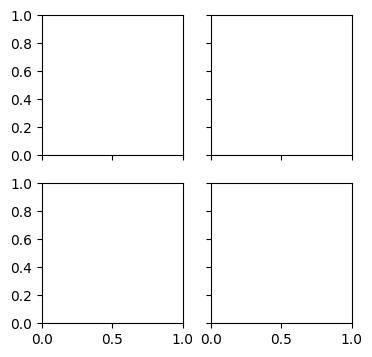

In [5]:
connection_pairs = ["L5TTPC_L5TTPC", "L23PC_L5TTPC", "L23PC_L23PC", "L4PC_L23PC"]
frequencies = [2, 5, 10, 20]

fig, axs = plt.subplots(2, 2, figsize=(4,4), sharex=True, sharey=True)
axs = axs.flatten()

for idx, freq in enumerate(frequencies):
    ax = axs[idx]
    for connection_pair in connection_pairs:
        epsp_ratio_df = pd.read_csv(str(connection_pair+"_EPSP_ratio.csv"))
        filtered_epsp_ratio_df = epsp_ratio_df[(epsp_ratio_df.frequency==freq) & (epsp_ratio_df.pathway==connection_pair)]
        
        grouped_data = filtered_epsp_ratio_df.groupby('pre_post_displacement')['EPSP_ratio'].agg(['mean', 'sem']).reset_index()
        
        dt = grouped_data["pre_post_displacement"]
        epsp_ratio = grouped_data["mean"]
        error = grouped_data["sem"]
        
        ax.errorbar(dt, epsp_ratio, yerr=error, fmt='-o', label=connection_pair)
    
    ax.set_title(f"Frequency = {freq} Hz")
    ax.set_xlim(-50, 50)
    ax.set_ylim(0.75, 2.0)
    ax.axhline(y=1, color='black', linestyle='--', linewidth=1)
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
    ax.set_xlabel(r'$\Delta t$ (ms)')
    ax.set_ylabel('EPSP ratio')

plt.tight_layout()
#plt.legend()
axs[0].legend(loc='upper left', fontsize='small')
plt.show()

Text(0, 0.5, 'EPSP ratio')

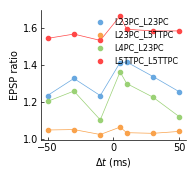

In [4]:
connection_pairs = ["L23PC_L23PC", "L23PC_L5TTPC", "L4PC_L23PC", "L5TTPC_L5TTPC"]
freq = 20
for connection_pair in connection_pairs:
    epsp_ratio_df = pd.read_csv(str(connection_pair+"_EPSP_ratio.csv"))
    filtered_epsp_ratio_df = epsp_ratio_df[(epsp_ratio_df.frequency==freq) & (epsp_ratio_df.pathway==connection_pair)]
    grouped_data = filtered_epsp_ratio_df.groupby('pre_post_displacement')['EPSP_ratio'].mean().reset_index()
    plt.scatter(grouped_data["pre_post_displacement"], grouped_data["EPSP_ratio"], label = connection_pair)
    plt.plot(grouped_data["pre_post_displacement"], grouped_data["EPSP_ratio"])
plt.legend()
plt.xlabel(r'$\Delta t$ (ms)')
plt.ylabel(r'EPSP ratio')